![A soccer pitch for an international match.](soccer-pitch.jpg)

You're working as a sports journalist at a major online sports media company, specializing in soccer analysis and reporting. You've been watching both men's and women's international soccer matches for a number of years, and your gut instinct tells you that more goals are scored in women's international football matches than men's. This would make an interesting investigative article that your subscribers are bound to love, but you'll need to perform a valid statistical hypothesis test to be sure!

While scoping this project, you acknowledge that the sport has changed a lot over the years, and performances likely vary a lot depending on the tournament, so you decide to limit the data used in the analysis to only official `FIFA World Cup` matches (not including qualifiers) since `2002-01-01`.

You create two datasets containing the results of every official men's and women's international football match since the 19th century, which you scraped from a reliable online source. This data is stored in two CSV files: `women_results.csv` and `men_results.csv`.

The question you are trying to determine the answer to is:

> Are more goals scored in women's international soccer matches than men's?

You assume a **10% significance level**, and use the following null and alternative hypotheses:

$H_0$ : The mean number of goals scored in women's international soccer matches is the same as men's.

$H_A$ : The mean number of goals scored in women's international soccer matches is greater than men's.

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg

mens = pd.read_csv("men_results.csv", parse_dates=["date"])
womens = pd.read_csv("women_results.csv", parse_dates=["date"])

In [183]:
mens.info()
mens.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44353 entries, 0 to 44352
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  44353 non-null  int64         
 1   date        44353 non-null  datetime64[ns]
 2   home_team   44353 non-null  object        
 3   away_team   44353 non-null  object        
 4   home_score  44353 non-null  int64         
 5   away_score  44353 non-null  int64         
 6   tournament  44353 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 2.4+ MB


,Unnamed: 0,home_score,away_score
count,44353.000000,44353.000000,44353.000000
mean,22176.000000,1.740559,1.178793
std,12803.752581,1.748722,1.394580
min,0.000000,0.000000,0.000000
25%,11088.000000,1.000000,0.000000
50%,22176.000000,1.000000,1.000000
75%,33264.000000,2.000000,2.000000
max,44352.000000,31.000000,21.000000


In [184]:
mens.value_counts("tournament")

tournament
Friendly                                17519
FIFA World Cup qualification             7878
UEFA Euro qualification                  2585
African Cup of Nations qualification     1932
FIFA World Cup                            964
                                        ...  
FIFA 75th Anniversary Cup                   1
Real Madrid 75th Anniversary Cup            1
Copa Confraternidad                         1
TIFOCO Tournament                           1
Évence Coppée Trophy                        1
Length: 141, dtype: int64

In [185]:
def prepare_data(df):
    # filter by date
    start_date = "2002-01-01"
    df = df[df["date"] > start_date]
    
    # filter by world cup
    df = df[df["tournament"] ==  "FIFA World Cup"]

    df["goals"] = df["home_score"] + df["away_score"]
    return df.reset_index()

In [186]:
mens = prepare_data(mens)
womens = prepare_data(womens)

384
200


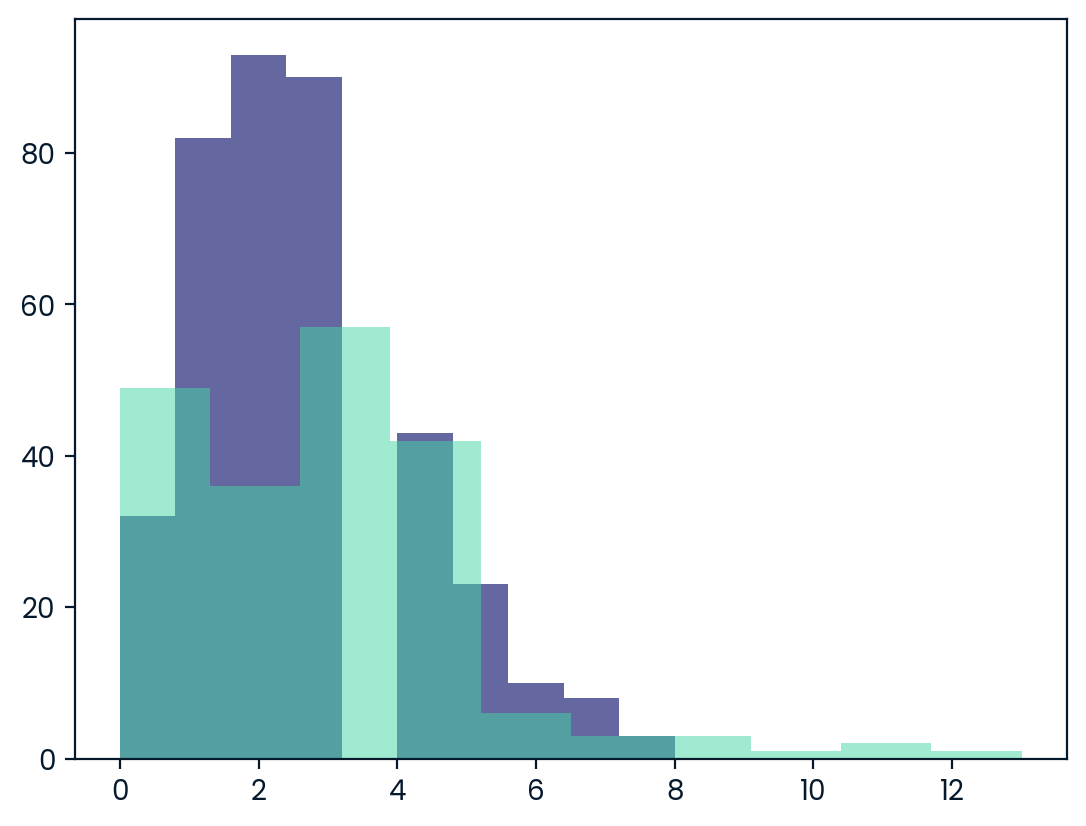

In [187]:
"""
H0: mean number of goals scored in women's international soccer matches is the same as men's.
H1: mean number of goals scored  !=
"""

alpha = 0.1

mens_length = len(mens) # 384 | > 30
womens_length = len(womens) # 200 | > 30
print(mens_length)
print(womens_length)

plt.hist(mens["goals"])
plt.hist(womens["goals"], alpha=0.5)
plt.show()

# positive skewness -> non-normal -> non-parametric -> mwu

In [188]:
mens_wide = pd.pivot(mens, columns="tournament", values="goals")
womens_wide = pd.pivot(womens, columns="tournament", values="goals")

res = pg.mwu(
    x=womens_wide["FIFA World Cup"],
    y=mens_wide["FIFA World Cup"],
    alternative="greater"
)

print(res["p-val"])

MWU    0.005107
Name: p-val, dtype: float64


In [189]:
result_dict = {
    "p_val": res["p-val"].iloc[0],
    "result": "reject"
}